PROJET_DIT


Chargement des packages

In [157]:

# Importation des bibliothèques nécessaires
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.metrics import classification_report
import joblib # Pour stocker le modèle
from sklearn.ensemble import RandomForestClassifier

Base de données insecurite alimentaire

Importation et nettoyage des données

In [158]:



data = pd.read_excel("D:/PROJET_DIT-20250506T153458Z-001/MES_PROJETS/DIEMMME/fast-api-food-security/DDDIEMMME.xlsx", sheet_name="Feuil2")

# Aperçu des données
print("Aperçu des données :")
#print(data.head())


Aperçu des données :


In [159]:
import numpy as np
# 1. Vérifier les valeurs manquantes
print("Valeurs manquantes avant nettoyage:")
print(data.isnull().sum())

Valeurs manquantes avant nettoyage:
id                                                              7759
q100_region                                                     7759
q101_departement                                                7759
q114_1_situation_matrimoniale_cm                                7765
q115_1_cm_souffre_t_il_maladie_chronique                        7765
                                                                ... 
q603_sauter_un_repas                                            7864
q604_manger_moins_que_ce_que_vous_auriez_du                     7894
q605_1_ne_plus_avoir_de_nourriture_pas_suffisamment_d_argent    7863
q606_1_avoir_faim_mais_ne_pas_manger                            7867
q607_1_passer_toute_une_journee_sans_manger                     7790
Length: 98, dtype: int64


In [160]:
# Remplacer les valeurs manquantes par la médiane
# pour les colonnes numériques uniquement
numeric_cols = data.select_dtypes(include=np.number).columns
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())


In [161]:
# 2. Suppression des doublons
print(f"Nombre de doublons avant suppression: {data.duplicated().sum()}")
data.drop_duplicates(inplace=True)

Nombre de doublons avant suppression: 7518


NORMALISATION DES VARIABLE NUMERIQUE

In [162]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
for col in data.select_dtypes(include=['object']).columns:  # Sélectionner les colonnes non numériques
    # Convert the column to string type before applying LabelEncoder
    data[col] = data[col].astype(str)
    data[col] = label_encoder.fit_transform(data[col])

In [163]:
from sklearn.preprocessing import OneHotEncoder

# Appliquer OneHotEncoder
# Replace 'sparse' with 'sparse_output'
from sklearn.preprocessing import OneHotEncoder

# Appliquer OneHotEncoder
# Replace 'sparse' with 'sparse_output'
one_hot_encoder = OneHotEncoder(sparse_output=False)
data_encoded = one_hot_encoder.fit_transform(data.select_dtypes(include=['object']))
data_encoded = pd.DataFrame(data_encoded, columns=one_hot_encoder.get_feature_names_out(data.select_dtypes(include=['object']).columns))

In [164]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data[data.select_dtypes(include=['float', 'int']).columns] = scaler.fit_transform(data.select_dtypes(include=['float', 'int']))


In [165]:
# Enregistrer le dataset encodé
chemin_projet = "D:/PROJET_DIT-20250506T153458Z-001/MES_PROJETS/DIEMMME/fast-api-food-security/"  # Remplacez par le chemin de votre répertoire
data.to_csv(chemin_projet + "data_encoded_1.csv", index=False)

print("Le fichier a été enregistré avec succès dans le répertoire de votre projet.")



Le fichier a été enregistré avec succès dans le répertoire de votre projet.


In [166]:
import pandas as pd

# Charger le fichier encodé
chemin_projet = "D:/PROJET_DIT-20250506T153458Z-001/MES_PROJETS/DIEMMME/fast-api-food-security/"
data_encoded = pd.read_csv(chemin_projet + "data_encoded_1.csv")

# Vérification rapide
print("Aperçu du fichier encodé :")
#print(data_encoded.head())
#print("Colonnes disponibles :", data_encoded.columns)

Aperçu du fichier encodé :


In [167]:
import pandas as pd

# Étape 1 : Définir la variable cible 'insécurité_alimentaire'
def definir_insécurité_alimentaire(row):
    # Insécurité sévère : au moins 1 privation critique avec score > 1.5
    if sum(row[col] > 1.5 for col in [
        'q605_1_ne_plus_avoir_de_nourriture_pas_suffisamment_d_argent',
        'q606_1_avoir_faim_mais_ne_pas_manger',
        'q607_1_passer_toute_une_journee_sans_manger'
    ]) >= 1:
        return 2
    # Insécurité modérée : au moins 2 privations légères/modérées avec score entre 0 et 1.5
    elif sum(0 < row[col] <= 1.5 for col in [
        'q600_inquiets_de_ne_pas_avoir_suffisamment_de_nourriture',
        'q601_ne_pas_manger_nourriture_saine_nutritive',
        'q602_manger_nourriture_peu_variee',
        'q603_sauter_un_repas',
        'q604_manger_moins_que_ce_que_vous_auriez_du'
    ]) >= 2:
        return 1
    # Aucune insécurité
    else:
        return 0



 PREPARATION DES DONNEES POUR LE MODELE

In [168]:
# Étape 2 : Appliquer la fonction au DataFrame encodé
data['insécurité_alimentaire'] = data_encoded.apply(definir_insécurité_alimentaire, axis=1)

# Étape 3 : Filtrer les cas modérés ou sévères
data_filtrée = data[data['insécurité_alimentaire'].isin([1, 2])]
data_encoded_filtré = data_encoded.loc[data_filtrée.index]  # Garder les mêmes lignes dans le dataset encodé

# Étape 4 : Calculer les corrélations avec la variable cible
data_encoded_filtré['insécurité_alimentaire'] = data_filtrée['insécurité_alimentaire']  # Ajouter la cible
correlations = data_encoded_filtré.corr()

# Étape 5 : Sélectionner les 10 variables les plus corrélées
top_features = correlations['insécurité_alimentaire'].abs().sort_values(ascending=False).iloc[1:11]
print("🔍 Les 10 variables les plus corrélées :")
print(top_features)

# Étape 6 : Créer un nouveau dataset avec ces variables + la cible
top_features_names = top_features.index.tolist()
data_reduced = data_encoded_filtré[top_features_names + ['insécurité_alimentaire']]
print("📊 Nouveau dataset réduit :")
#print(data_reduced.head())


🔍 Les 10 variables les plus corrélées :
q606_1_avoir_faim_mais_ne_pas_manger                            0.779630
q605_1_ne_plus_avoir_de_nourriture_pas_suffisamment_d_argent    0.775247
q604_manger_moins_que_ce_que_vous_auriez_du                     0.680129
q607_1_passer_toute_une_journee_sans_manger                     0.630765
q603_sauter_un_repas                                            0.625893
q207_1_principale_source_energie_cuisson                        0.617320
PRATIQUE_PECHE                                                  0.550865
q602_manger_nourriture_peu_variee                               0.471341
q601_ne_pas_manger_nourriture_saine_nutritive                   0.442618
MILIEU_RESIDENCE                                                0.435433
Name: insécurité_alimentaire, dtype: float64
📊 Nouveau dataset réduit :


In [169]:
# Variables explicatives (features) et cible (target)
X = data_reduced.drop(columns=['insécurité_alimentaire'])  # Toutes les colonnes sauf la cible
y = data_reduced['insécurité_alimentaire']  # La variable cible # C

DIVISION EN TRAIN TEST DU DATASET

In [175]:
from sklearn.model_selection import train_test_split

# Division 80% entraînement, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vérifier les tailles des ensembles
print("Taille de l'ensemble d'entraînement :", X_train.shape)
print("Taille de l'ensemble de test :", X_test.shape)


Taille de l'ensemble d'entraînement : (4043, 8)
Taille de l'ensemble de test : (1011, 8)


In [176]:
# Remapping des classes : 1 → 0 (modérée), 2 → 1 (sévère)
y_train_mapped = y_train.replace({1: 0, 2: 1})
y_test_mapped = y_test.replace({1: 0, 2: 1})


ENTRAINEMENT DES MODELES

In [177]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, roc_curve, auc
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import seaborn as sns
import joblib

# 🔹 Colonnes retenues pour le modèle
selected_features = [
    "q600_inquiets_de_ne_pas_avoir_suffisamment_de_nourriture",
    "q601_ne_pas_manger_nourriture_saine_nutritive",
    "q602_manger_nourriture_peu_variee",
    "q603_sauter_un_repas",
    "q604_manger_moins_que_ce_que_vous_auriez_du",
    "q605_1_ne_plus_avoir_de_nourriture_pas_suffisamment_d_argent",
    "q606_1_avoir_faim_mais_ne_pas_manger",
    "q607_1_passer_toute_une_journee_sans_manger"
]

print("✅ Variables utilisées :", selected_features)

# 🔧 Charger le dataset
df = pd.read_csv("data_encoded_1.csv")

# ⚠️ Vérification des colonnes
missing = [col for col in selected_features if col not in df.columns]
if missing:
    raise ValueError(f"Colonnes manquantes dans le dataset : {missing}")

# 🔧 Définir X et y (⚠️ adapte la cible selon ton dataset)
X = df[selected_features]
y = df["HHS__r_AP"]  # exemple de variable cible, à adapter

# 🔁 Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 🔧 Préprocesseur unique
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), selected_features),
        ("num", StandardScaler(), [])  # ajoute ici si tu as des colonnes numériques
    ]
)

# 🔁 Pipelines RF et XGB
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=100, random_state=42))
])

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ))
])

# 🔁 Entraînement
rf_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)

# 🔍 Prédictions
rf_preds = rf_pipeline.predict(X_test)
xgb_preds = xgb_pipeline.predict(X_test)

print("📊 Rapport RandomForest :")
print(classification_report(y_test, rf_preds))

print("📊 Rapport XGBoost :")
print(classification_report(y_test, xgb_preds))

# 🔁 Cross-validation
rf_cv_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=5, scoring='accuracy')
xgb_cv_scores = cross_val_score(xgb_pipeline, X_train, y_train, cv=5, scoring='accuracy')

print(f"✅ Score moyen CV (Random Forest) : {rf_cv_scores.mean():.4f}")
print(f"✅ Score moyen CV (XGBoost) : {xgb_cv_scores.mean():.4f}")

# 🔍 Comparaison des performances
rf_auc = roc_auc_score(y_test, rf_preds)
xgb_auc = roc_auc_score(y_test, xgb_preds)

rf_acc = accuracy_score(y_test, rf_preds)
xgb_acc = accuracy_score(y_test, xgb_preds)

print(f"✅ RandomForest - Accuracy: {rf_acc:.4f}, AUC: {rf_auc:.4f}, CV: {rf_cv_scores.mean():.4f}")
print(f"✅ XGBoost       - Accuracy: {xgb_acc:.4f}, AUC: {xgb_auc:.4f}, CV: {xgb_cv_scores.mean():.4f}")

# 🔹 Courbes ROC comparatives
rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]
xgb_proba = xgb_pipeline.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)

auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})", color='blue')
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.2f})", color='orange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Classifieur aléatoire')
plt.title("Courbes ROC - Comparaison RF vs XGB", fontsize=14)
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# 🔍 Importances comparées regroupées
feature_names_transformed = preprocessor.get_feature_names_out()
rf_importances = rf_pipeline.named_steps["model"].feature_importances_
xgb_importances = xgb_pipeline.named_steps["model"].feature_importances_

df_importances = pd.DataFrame({
    "Feature": feature_names_transformed,
    "RandomForest": rf_importances,
    "XGBoost": xgb_importances
})

df_importances["Variable"] = df_importances["Feature"].str.rsplit("_", n=1).str[0]
df_grouped = df_importances.groupby("Variable")[["RandomForest", "XGBoost"]].sum().reset_index()

print("✅ Importances regroupées par variable :")
print(df_grouped)

df_melted = df_grouped.melt(id_vars="Variable",
                            value_vars=["RandomForest", "XGBoost"],
                            var_name="Modèle",
                            value_name="Importance")

plt.figure(figsize=(8, 6))
sns.barplot(x="Importance", y="Variable", hue="Modèle", data=df_melted)
plt.title("Comparaison des importances regroupées - RF vs XGB", fontsize=14)
plt.xlabel("Importance totale")
plt.ylabel("Variable")
plt.legend(title="Modèle")
plt.tight_layout()
plt.show()

# 🔍 Choix du meilleur modèle
if xgb_auc >= rf_auc:
    best_model = xgb_pipeline
    best_name = "XGBoost"
else:
    best_model = rf_pipeline
    best_name = "RandomForest"

print(f"🎯 Meilleur modèle sélectionné : {best_name}")

# 🔹 Sauvegarde du meilleur modèle avec les features
joblib.dump({"model": best_model, "features": selected_features}, "modele_food_insecurity_best.pkl")

print("🎉 Meilleur modèle sauvegardé avec succès !")


✅ Variables utilisées : ['q600_inquiets_de_ne_pas_avoir_suffisamment_de_nourriture', 'q601_ne_pas_manger_nourriture_saine_nutritive', 'q602_manger_nourriture_peu_variee', 'q603_sauter_un_repas', 'q604_manger_moins_que_ce_que_vous_auriez_du', 'q605_1_ne_plus_avoir_de_nourriture_pas_suffisamment_d_argent', 'q606_1_avoir_faim_mais_ne_pas_manger', 'q607_1_passer_toute_une_journee_sans_manger']


ValueError: Unknown label type: continuous. Maybe you are trying to fit a classifier, which expects discrete classes on a regression target with continuous values.

RAPPORTS DE CLASSIFICATION

Importances des variables (comparaison cote à cote avec le graphique)

✅ Importances regroupées par variable :
                                            Variable  RandomForest   XGBoost
0  cat__q601_ne_pas_manger_nourriture_saine_nutri...      0.113421  0.021487
1                          cat__q603_sauter_un_repas      0.116517  0.007438
2   cat__q604_manger_moins_que_ce_que_vous_auriez_du      0.191356  0.169977
3  cat__q605_1_ne_plus_avoir_de_nourriture_pas_su...      0.235316  0.390376
4          cat__q606_1_avoir_faim_mais_ne_pas_manger      0.343390  0.410723


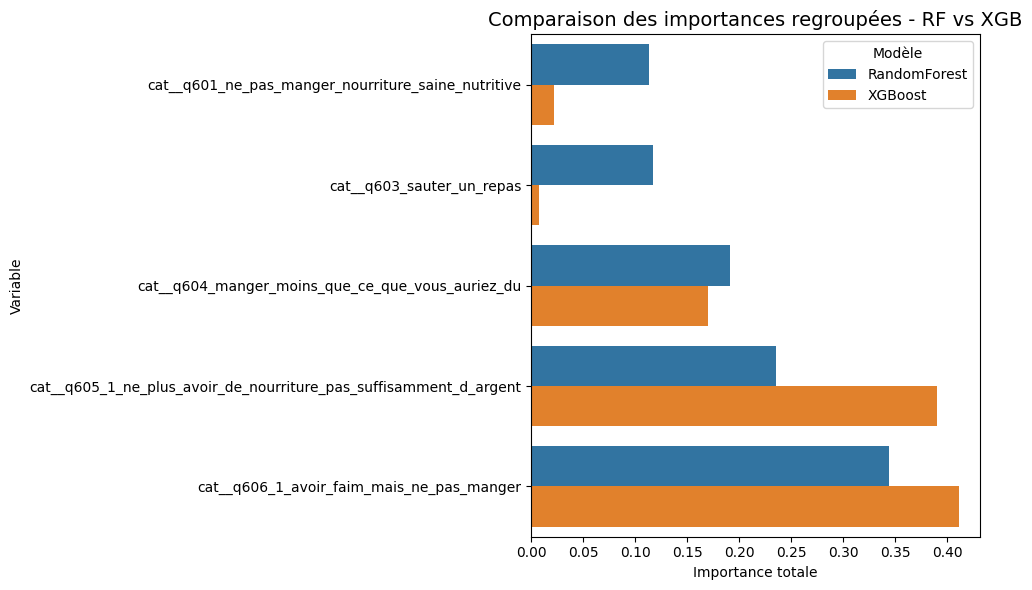

In [154]:
import seaborn as sns

# 🔍 Importances comparées
feature_names_transformed = preprocessor.get_feature_names_out()
rf_importances = rf_pipeline.named_steps["model"].feature_importances_
xgb_importances = xgb_pipeline.named_steps["model"].feature_importances_

df_importances = pd.DataFrame({
    "Feature": feature_names_transformed,
    "RandomForest": rf_importances,
    "XGBoost": xgb_importances
})

# ✅ Extraire le nom de la variable avant la dernière valeur encodée
df_importances["Variable"] = df_importances["Feature"].str.rsplit("_", n=1).str[0]

# ✅ Regrouper par variable
df_grouped = df_importances.groupby("Variable")[["RandomForest", "XGBoost"]].sum().reset_index()

print("✅ Importances regroupées par variable :")
print(df_grouped)

# 🔹 Graphique comparatif regroupé
df_melted = df_grouped.melt(id_vars="Variable",
                            value_vars=["RandomForest", "XGBoost"],
                            var_name="Modèle",
                            value_name="Importance")

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Variable", hue="Modèle", data=df_melted)
plt.title("Comparaison des importances regroupées - RF vs XGB", fontsize=14)
plt.xlabel("Importance totale")
plt.ylabel("Variable")
plt.legend(title="Modèle")
plt.tight_layout()
plt.show()


Prédiction sur les bases train et test

In [128]:
# 🔹 RandomForest - prédictions
rf_train_pred = rf_pipeline.predict(X_train)
rf_test_pred = rf_pipeline.predict(X_test)
print("RandomForest - Prédictions test :", rf_test_pred[:20])

# 🔹 XGBoost - prédictions
xgb_train_pred = xgb_pipeline.predict(X_train)
xgb_test_pred = xgb_pipeline.predict(X_test)
print("XGBoost - Prédictions test :", xgb_test_pred[:20])


RandomForest - Prédictions test : [0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
XGBoost - Prédictions test : [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]


DEPLOIMENT DU MODELE

In [131]:
joblib.dump({"model": rf_pipeline, "features": selected_features}, "modele_food_insecurity_rf.pkl")
joblib.dump({"model": xgb_pipeline, "features": selected_features}, "modele_food_insecurity_xgb.pkl")
print("✅ Modèles sauvegardés avec succès !")

✅ Modèles sauvegardés avec succès !


In [132]:
import joblib

# Charger le modèle sauvegardé
rf_bundle = joblib.load("modele_food_insecurity_rf.pkl")

# Afficher les colonnes sauvegardées
print("Features dans le modèle :", rf_bundle["features"])


Features dans le modèle : ['q607_1_passer_toute_une_journee_sans_manger', 'q603_sauter_un_repas', 'q604_manger_moins_que_ce_que_vous_auriez_du', 'q605_1_ne_plus_avoir_de_nourriture_pas_suffisamment_d_argent', 'q606_1_avoir_faim_mais_ne_pas_manger']


In [ ]:
https://fast-api-food-security.onrender.com/predict